In [1]:
from unet import *
import tensorflow as tf 

In [2]:
# --- Aggregate tile pairs from a list of sites ---
def aggregate_tile_pairs(sites, folder_path):
    """
    Aggregates all tile pairs from the provided sites.
    Each pair is a tuple: (img_path, mask_path, snow_ratio)
    """
    img_paths = glob.glob(os.path.join(folder_path, "*_img.npy"))
    tile_pairs = []
    for ip in img_paths:
        site = os.path.basename(ip).split("_")[0]
        if site in sites:
            mp = ip.replace("_img.npy", "_msk.npy")
            if os.path.exists(mp):
                # Compute snow ratio
                mask = np.load(mp)
                ratio = np.mean(mask)
                tile_pairs.append((ip, mp, ratio))
    return tile_pairs

# --- Bin tile pairs by snow ratio ---
def bin_tile_pairs(tile_pairs, snow_vs_notsnow_ratio_distribution):
    """
    Bins tile pairs (list of (img_path, mask_path, ratio)) into low, mid, and high lists.
    snow_vs_notsnow_ratio_distribution: (high_threshold, low_threshold)
    """
    high_threshold = snow_vs_notsnow_ratio_distribution[0]  # e.g. 0.8
    low_threshold = snow_vs_notsnow_ratio_distribution[1]   # e.g. 0.2
    
    low_bin = [(img, msk) for img, msk, ratio in tile_pairs if ratio <= low_threshold]
    high_bin = [(img, msk) for img, msk, ratio in tile_pairs if ratio >= high_threshold]
    mid_bin = [(img, msk) for img, msk, ratio in tile_pairs if low_threshold < ratio < high_threshold]
    
    random.shuffle(low_bin)
    random.shuffle(mid_bin)
    random.shuffle(high_bin)
    return low_bin, mid_bin, high_bin



def uniform_sample_by_ratio(tile_pairs, num_bins=100, seed=None):
    """
    Given tile_pairs [(img, mask, ratio), …], split into num_bins bins by ratio,
    then sample from each bin the size of the smallest bin, returning a flat list.
    """
    if seed is not None:
        random.seed(seed)

    # 1) Assign each pair to a bin index 0..num_bins-1
    bins = defaultdict(list)
    for img_path, mask_path, ratio in tile_pairs:
        # ensure ratio in [0,1]
        r = min(max(ratio, 0.0), 1.0)
        # bin width = 1/num_bins; ratio* num_bins gives [0, num_bins]
        idx = min(int(r * num_bins), num_bins - 1)
        bins[idx].append((img_path, mask_path, ratio))

    # 2) Find smallest bin size
    sizes = [ len(bins[i]) for i in range(num_bins) ]
    min_size = min(sizes)
    print(f"Bin counts: {sizes}")
    print(f"→ Sampling {min_size} tiles from each of {num_bins} bins → total {min_size * num_bins}")

    # 3) Sample min_size from each bin
    balanced = []
    for i in range(num_bins):
        group = bins[i]
        # if a bin has exactly min_size, random.sample works
        sampled = random.sample(group, min_size)
        balanced.extend(sampled)

    # 4) Shuffle the final list so you don’t train in sorted‐by‐ratio order
    random.shuffle(balanced)
    return balanced

# --- USAGE: replace your three‐bin code with this ---
# train_split is your 70% in‐sample training list of (img, msk, ratio)
balanced_train_pairs = uniform_sample_by_ratio(
    train_split,
    num_bins=100,
    seed=42
)

# Now build your dataset / DataLoader on balanced_train_pairs,
# instead of on the low/mid/high bins.
# For example, if you were doing something like:
# train_dataset = TileDataset(balanced_train_pairs, ...)
# train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


# --- Sampling from bins ---
def sample_from_bins(low_bin, mid_bin, high_bin, target_number, mid_low_high_ratio_distribution):
    """
    Samples tile pairs from each bin according to the provided distribution.
    mid_low_high_ratio_distribution: (mid_ratio, low_ratio, high_ratio)
    """
    mid_ratio, low_ratio, high_ratio = mid_low_high_ratio_distribution
    required_mid = int(target_number * mid_ratio)
    required_low = int(target_number * low_ratio)
    required_high = int(target_number * high_ratio)
    
    if len(mid_bin) < required_mid:
        print(f"Limiting factor for mid bin: required {required_mid}, available {len(mid_bin)}")
    if len(low_bin) < required_low:
        print(f"Limiting factor for low bin: required {required_low}, available {len(low_bin)}")
    if len(high_bin) < required_high:
        print(f"Limiting factor for high bin: required {required_high}, available {len(high_bin)}")
    
    actual_mid = min(len(mid_bin), required_mid)
    actual_low = min(len(low_bin), required_low)
    actual_high = min(len(high_bin), required_high)
    
    sampled_mid = mid_bin[:actual_mid]
    sampled_low = low_bin[:actual_low]
    sampled_high = high_bin[:actual_high]
    
    # Remove sampled items to avoid re-use if needed.
    del mid_bin[:actual_mid]
    del low_bin[:actual_low]
    del high_bin[:actual_high]
    
    sampled_tiles = sampled_mid + sampled_low + sampled_high
    random.shuffle(sampled_tiles)
    return sampled_tiles

def run_unet_training(
    folder_path,
    training_bins,                # tuple: (low_bin, mid_bin, high_bin) for training (70% split)
    in_sample_val_tiles,          # list of in-sample validation tiles (30% split)
    in_sample_test_tiles,         # list of in-sample testing tiles (30% split)
    out_of_sample_test_tiles,     # list of out-of-sample testing tiles (from testing sites)
    max_training_tiles,           # maximum training tiles to sample from binned training data
    mid_low_high_ratio_distribution, 
    snow_vs_notsnow_ratio_distribution,
    img_height,
    img_width,
    img_channels,
    batch_size,
    epochs,
    comet_api_key,
    comet_project_name,
    comet_workspace,
    model_instance_name=None
):
    import math, datetime
    # Unpack training bins.
    low_bin, mid_bin, high_bin = training_bins
    # Sample training tiles from bins (using copies so original bins remain unchanged).
    training_tiles = sample_from_bins(low_bin.copy(), mid_bin.copy(), high_bin.copy(), max_training_tiles, mid_low_high_ratio_distribution)
    print(f"Training tiles selected (after binning): {len(training_tiles)}")
    
    # Create TensorFlow datasets.
    # Note: For training and in-sample validation we use shuffle=True (which also calls repeat())
    train_dataset = make_dataset(training_tiles, batch_size=batch_size, shuffle=True, valid_threshold=1.0)
    val_dataset   = make_dataset(in_sample_val_tiles, batch_size=batch_size, shuffle=False, valid_threshold=1.0)
    in_sample_test_dataset = make_dataset(in_sample_test_tiles, batch_size=batch_size, shuffle=False, valid_threshold=1.0)
    out_of_sample_test_dataset = make_dataset(out_of_sample_test_tiles, batch_size=batch_size, shuffle=False, valid_threshold=1.0)
    
    # Count samples.
    num_train = len(training_tiles)
    num_val = len(in_sample_val_tiles)
    num_in_sample_test = len(in_sample_test_tiles)
    num_out_of_sample_test = len(out_of_sample_test_tiles)
    print("\nFinal split counts:")
    print("Number of training pairs:", num_train)
    print("Number of in-sample validation pairs:", num_val)
    print("Number of in-sample testing pairs:", num_in_sample_test)
    print("Number of out-of-sample testing pairs:", num_out_of_sample_test)
    
    # Build the U-Net model.
    my_unet = unet_model(n_classes=1, img_height=img_height, img_width=img_width, img_channels=img_channels)
    
    # Prepare metadata.
    date_str = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M")
    dataset_info = {
        "num_train_samples": num_train,
        "num_in_sample_val_samples": num_val,
        "num_in_sample_test_samples": num_in_sample_test,
        "num_out_of_sample_test_samples": num_out_of_sample_test,
        "image_shape": (img_height, img_width, img_channels)
    }
    
    # Create and log a Comet.ml experiment.
    from comet_ml import Experiment
    experiment = Experiment(
        api_key=comet_api_key,
        project_name=comet_project_name,
        workspace=comet_workspace
    )
    if model_instance_name is not None:
        experiment.set_name(model_instance_name)
    experiment.log_parameters({
        "batch_size": batch_size,
        "epochs": epochs,
        "img_height": img_height,
        "img_width": img_width,
        "img_channels": img_channels,
        "max_training_tiles": max_training_tiles,
        "in_sample_validation_tiles": num_val,
        "in_sample_testing_tiles": num_in_sample_test,
        "out_of_sample_testing_tiles": num_out_of_sample_test,
        "mid_low_high_ratio_distribution": mid_low_high_ratio_distribution,
        "snow_vs_notsnow_ratio_distribution": snow_vs_notsnow_ratio_distribution
    })
    
    # Compute steps per epoch.
    steps_per_epoch = math.ceil(num_train / batch_size)
    validation_steps = math.ceil(num_val / batch_size)
    
    # Train the model.
    model, history = train_model(
        unet_model=my_unet,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        date_str=date_str,
        dataset_info=dataset_info,
        batch_size=batch_size,
        epochs=epochs,
        experiment=experiment,
        instance_name=model_instance_name
    )
    
    # Evaluate on in-sample testing.
    in_sample_steps = math.ceil(num_in_sample_test / batch_size)
    in_sample_eval_results = my_unet.evaluate(in_sample_test_dataset, steps=in_sample_steps, return_dict=True)
    experiment.log_metric("in_sample_testing_combined_loss", in_sample_eval_results.get("loss"))
    experiment.log_metric("in_sample_testing_dice_coef", in_sample_eval_results.get("dice_coef"))
    
    # Evaluate on out-of-sample testing.
    out_of_sample_steps = math.ceil(num_out_of_sample_test / batch_size)
    out_of_sample_eval_results = my_unet.evaluate(out_of_sample_test_dataset, steps=out_of_sample_steps, return_dict=True)
    experiment.log_metric("out_of_sample_testing_combined_loss", out_of_sample_eval_results.get("loss"))
    experiment.log_metric("out_of_sample_testing_dice_coef", out_of_sample_eval_results.get("dice_coef"))
    
    experiment.end()
    return my_unet, history, in_sample_eval_results, out_of_sample_eval_results

In [3]:
# Comet ML and Hyperparameters that are the same for all models
folder_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output"

comet_api_key = "HMIpeLQjlVPMeWB9fDhY9Pv11"
comet_project_name = "unet-snow-model"
comet_workspace = "reversedpuppy"

IMG_HEIGHT = 512
IMG_WIDTH = 512
IMG_CHANNELS = 3

max_training_tiles = 22000

In [4]:
#Generate In sample and out of sample Validation and Testing tiles sets

training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy"]
testing_sites = ["StrandHill", "VirginiaBasin"]

max_in_sample_validation_tiles = 4400
max_in_sample_testing_tiles = 2200
max_out_of_sample_testing_tiles = 2200

# Aggregate pairs.
all_training_pairs = aggregate_tile_pairs(training_sites, folder_path)
all_testing_pairs = aggregate_tile_pairs(testing_sites, folder_path)
print(f"Total aggregated training pairs: {len(all_training_pairs)}")
print(f"Total aggregated testing pairs (out-of-sample): {len(all_testing_pairs)}")

# --- Split training pairs into 70% (for training) and 30% (for in-sample validation+testing) ---
train_split, in_sample_split = train_test_split(all_training_pairs, test_size=0.3, random_state=42)
print(f"70% training split count: {len(train_split)}")
print(f"30% in-sample split count: {len(in_sample_split)}")

# --- From the in-sample split, sample fixed numbers for validation and testing ---
total_in_sample = len(in_sample_split)
if max_in_sample_validation_tiles + max_in_sample_testing_tiles <= total_in_sample:
    shuffled = random.sample(in_sample_split, total_in_sample)
    in_sample_val_tiles = shuffled[:max_in_sample_validation_tiles]
    in_sample_test_tiles = shuffled[max_in_sample_validation_tiles:max_in_sample_validation_tiles+max_in_sample_testing_tiles]
else:
    in_sample_val_tiles = random.sample(in_sample_split, min(max_in_sample_validation_tiles, total_in_sample))
    in_sample_test_tiles = random.sample(in_sample_split, min(max_in_sample_testing_tiles, total_in_sample))
print(f"In-sample validation tiles count: {len(in_sample_val_tiles)}")
print(f"In-sample testing tiles count: {len(in_sample_test_tiles)}")

# --- Out-of-sample testing: sample from testing pairs ---
out_of_sample_test_tiles = random.sample(all_testing_pairs, min(len(all_testing_pairs), max_out_of_sample_testing_tiles))
print(f"Out-of-sample testing tiles count: {len(out_of_sample_test_tiles)}")

Total aggregated training pairs: 118039
Total aggregated testing pairs (out-of-sample): 18212
70% training split count: 82627
30% in-sample split count: 35412
In-sample validation tiles count: 4400
In-sample testing tiles count: 2200
Out-of-sample testing tiles count: 2200


In [5]:
# --- Bin the 70% training split for training ---
snow_vs_notsnow_ratio_distribution = (0.9, 0.1)  # (high_threshold, low_threshold)

low_bin, mid_bin, high_bin = bin_tile_pairs(train_split, snow_vs_notsnow_ratio_distribution)
print(f"Training bins (70% split): Low: {len(low_bin)}, Mid: {len(mid_bin)}, High: {len(high_bin)}")
training_bins = (low_bin, mid_bin, high_bin)

Training bins (70% split): Low: 58407, Mid: 11718, High: 12502


Training tiles selected (after binning): 22000

Final split counts:
Number of training pairs: 22000
Number of in-sample validation pairs: 4400
Number of in-sample testing pairs: 2200
Number of out-of-sample testing pairs: 2200
Model summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 16  432         ['input_1[0][0]']                
                                )                                                                 
                                                  

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/df7c596f933a4716b8013d5454af6a67

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 1375
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


1375/1375 [==============================] - ETA: 0s - loss: 0.4275 - accuracy: 0.9581 - precision: 0.9592 - recall: 0.9552 - dice_coef: 0.9263   
Epoch 1: val_loss improved from inf to 0.13956, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
1375/1375 [==============================] - 520s 368ms/step - loss: 0.4275 - accuracy: 0.9581 - precision: 0.9592 - recall: 0.9552 - dice_coef: 0.9263 - val_loss: 0.1396 - val_accuracy: 0.9628 - val_precision: 0.9731 - val_recall: 0.8487 - val_dice_coef: 0.8730
Epoch 2/20
1375/1375 [==============================] - ETA: 0s - loss: 0.0905 - accuracy: 0.9664 - precision: 0.9644 - recall: 0.9672 - dice_coef: 0.9527   
Epoch 2: val_loss improved from 0.13956 to 0.06203, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2: learnin

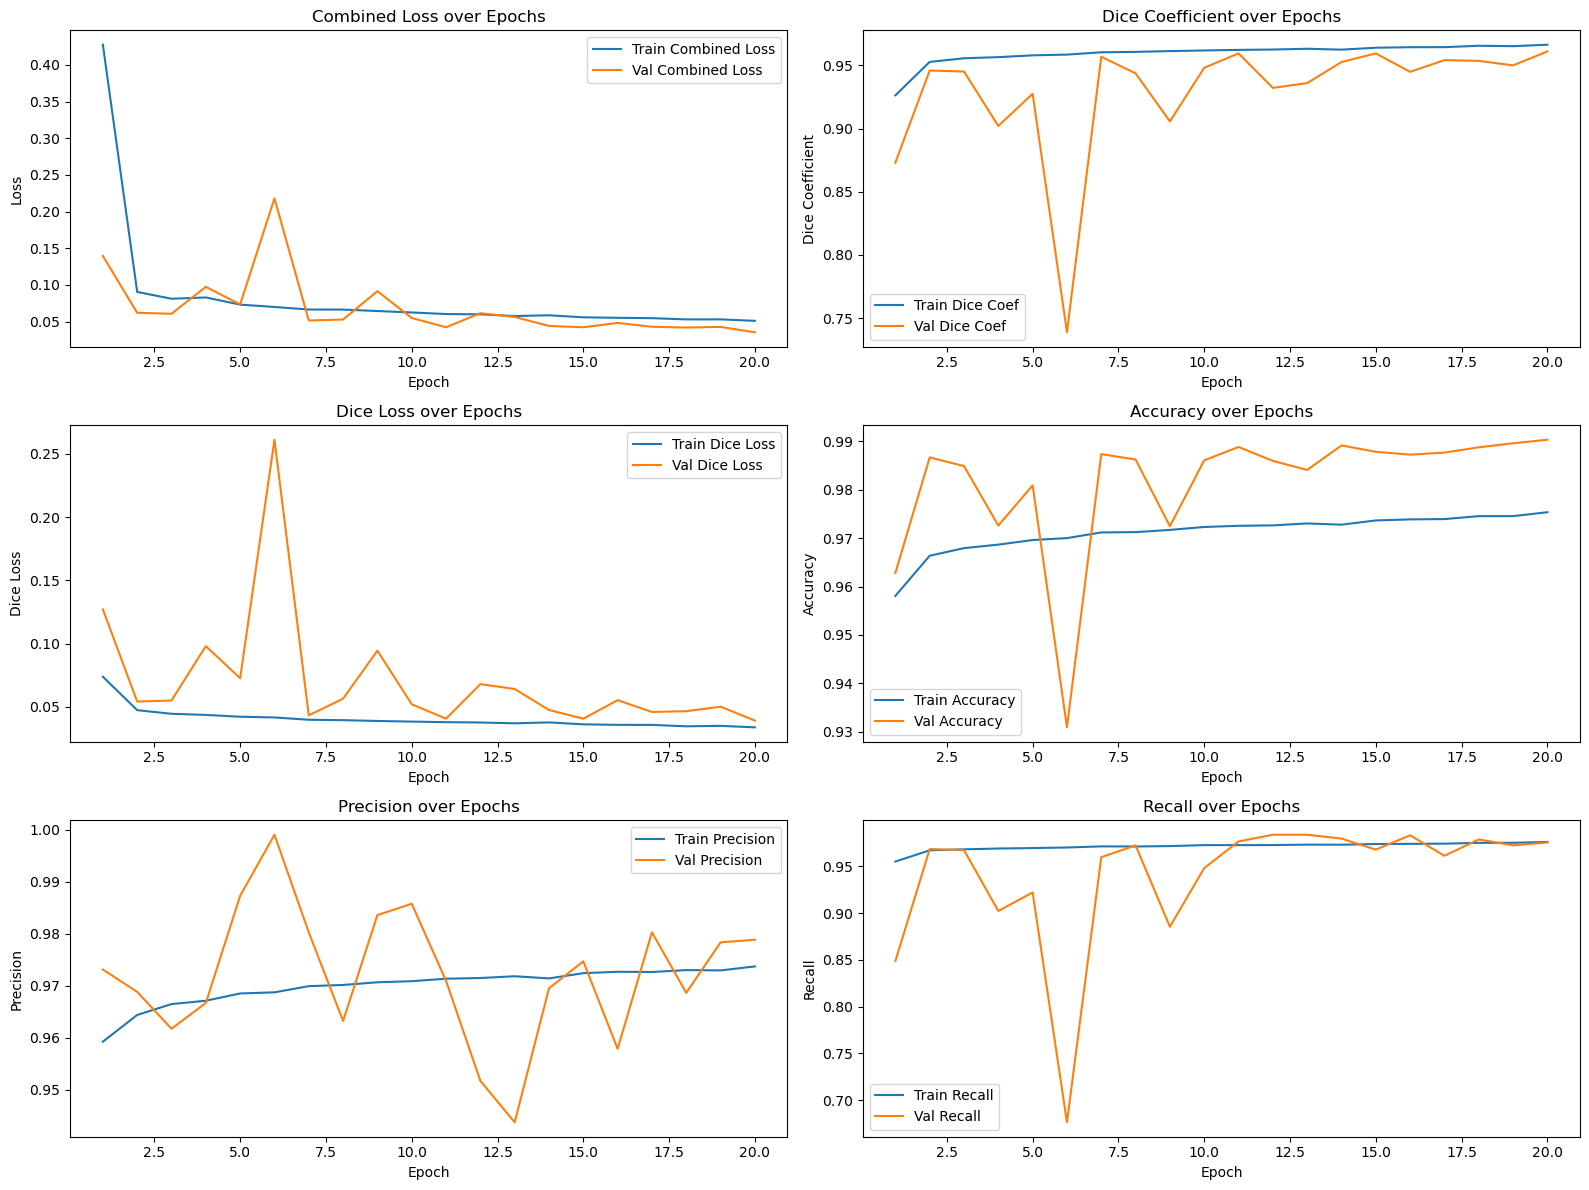


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_10.1_2025-04-01-13-11\Model_Data
138/138 [==============================] - 30s 216ms/step - loss: 0.0846 - accuracy: 0.9813 - precision: 0.9083 - recall: 0.9602 - dice_coef: 0.8895


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_10.1
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/df7c596f933a4716b8013d5454af6a67
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                       : (0.9580721855163574, 0.9753383994102478)
COMET INFO:     batch_accuracy [2760]               : (0.5351760387420654, 0.9873888492584229)
COMET INFO:     batch_dice_coef [2760]              : (0.41896963119506836, 0.9825292229652405)
COMET INFO:     batch_loss [2760]                   : (0.037606481462717056, 47.152835845947266)
COMET INFO:     batch_precision [2760]              : (0.681104838848114, 0.9918453693389893)
COM

In [6]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.3, 0.3)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_10.1"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

Training tiles selected (after binning): 22000

Final split counts:
Number of training pairs: 22000
Number of in-sample validation pairs: 4400
Number of in-sample testing pairs: 2200
Number of out-of-sample testing pairs: 2200
Model summary:
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_33 (Conv2D)             (None, 512, 512, 16  432         ['input_2[0][0]']                
                                )                                                                 
                                                

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/64a06c8c1d8d4124a9e706e29037ddbb

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 1375
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


1375/1375 [==============================] - ETA: 0s - loss: 0.4336 - accuracy: 0.9603 - precision_1: 0.9473 - recall_1: 0.9518 - dice_coef: 0.9119   
Epoch 1: val_loss improved from inf to 0.13030, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
1375/1375 [==============================] - 507s 366ms/step - loss: 0.4336 - accuracy: 0.9603 - precision_1: 0.9473 - recall_1: 0.9518 - dice_coef: 0.9119 - val_loss: 0.1303 - val_accuracy: 0.9730 - val_precision_1: 0.8990 - val_recall_1: 0.9837 - val_dice_coef: 0.8921
Epoch 2/20
1375/1375 [==============================] - ETA: 0s - loss: 0.0969 - accuracy: 0.9682 - precision_1: 0.9586 - recall_1: 0.9603 - dice_coef: 0.9449   
Epoch 2: val_loss did not improve from 0.13030
Epoch 2: learning_rate = 0.000954
1375/1375 [==============================] - 502s 365ms/step - loss: 0.0969 - accuracy: 0.9682 - precision_1: 0.

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:258: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,0].legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:268: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,1].legend()


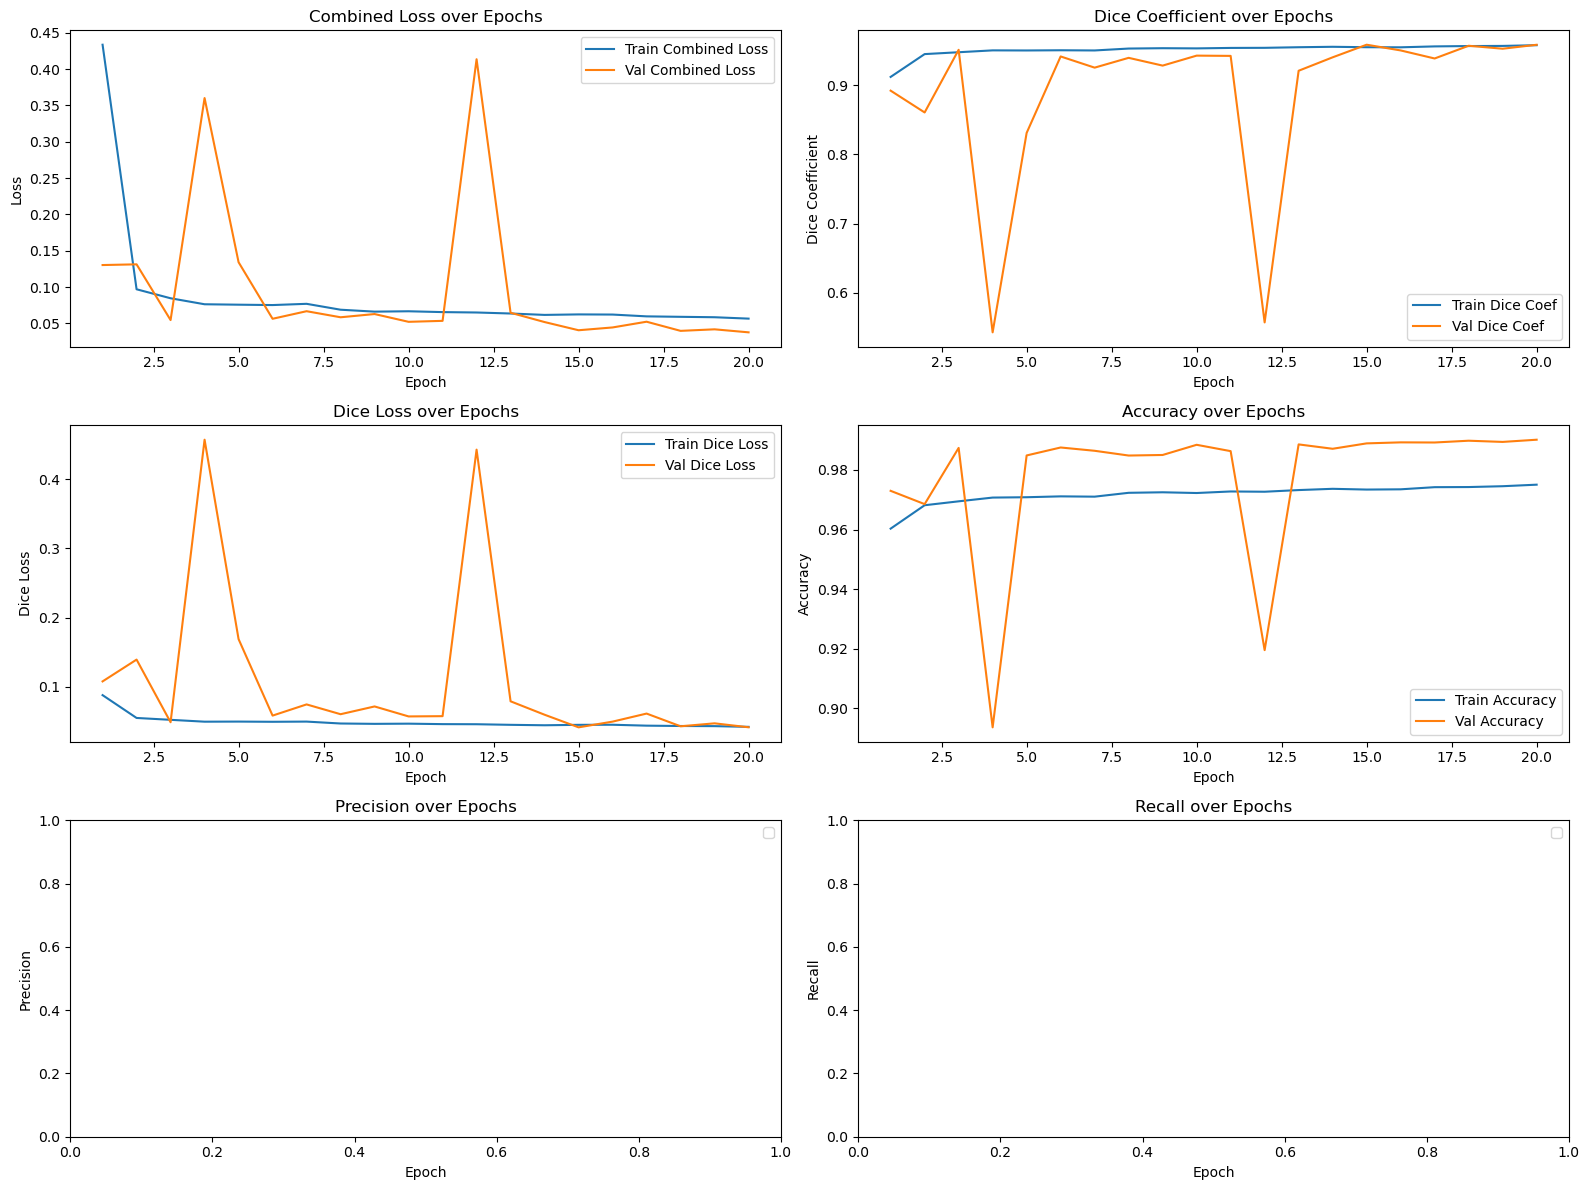


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_10.2_2025-04-01-16-00\Model_Data
138/138 [==============================] - 31s 220ms/step - loss: 0.0837 - accuracy: 0.9828 - precision_1: 0.9136 - recall_1: 0.9655 - dice_coef: 0.8905


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_10.2
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/64a06c8c1d8d4124a9e706e29037ddbb
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                       : (0.9602993726730347, 0.9750521779060364)
COMET INFO:     batch_accuracy [2760]               : (0.4931976795196533, 0.9933450222015381)
COMET INFO:     batch_dice_coef [2760]              : (0.46144959330558777, 0.9842852354049683)
COMET INFO:     batch_loss [2760]                   : (0.02342590130865574, 47.138328552246094)
COMET INFO:     batch_precision_1 [2760]            : (0.41432929039001465, 0.9961479902267456)
CO

In [7]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.4, 0.2)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_10.2"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,`
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

Training tiles selected (after binning): 22000

Final split counts:
Number of training pairs: 22000
Number of in-sample validation pairs: 4400
Number of in-sample testing pairs: 2200
Number of out-of-sample testing pairs: 2200
Model summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 16  432         ['input_1[0][0]']                
                                )                                                                 
                                                  

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/9c238881c5464ccba5eaf8934ae4c836

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 1375
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


1375/1375 [==============================] - ETA: 0s - loss: 0.4743 - accuracy: 0.9617 - precision: 0.9315 - recall: 0.9386 - dice_coef: 0.8930   
Epoch 1: val_loss improved from inf to 0.10939, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
1375/1375 [==============================] - 513s 365ms/step - loss: 0.4743 - accuracy: 0.9617 - precision: 0.9315 - recall: 0.9386 - dice_coef: 0.8930 - val_loss: 0.1094 - val_accuracy: 0.9774 - val_precision: 0.9608 - val_recall: 0.9329 - val_dice_coef: 0.9074
Epoch 2/20
1375/1375 [==============================] - ETA: 0s - loss: 0.1080 - accuracy: 0.9695 - precision: 0.9477 - recall: 0.9485 - dice_coef: 0.9307  
Epoch 2: val_loss improved from 0.10939 to 0.09021, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2: learning

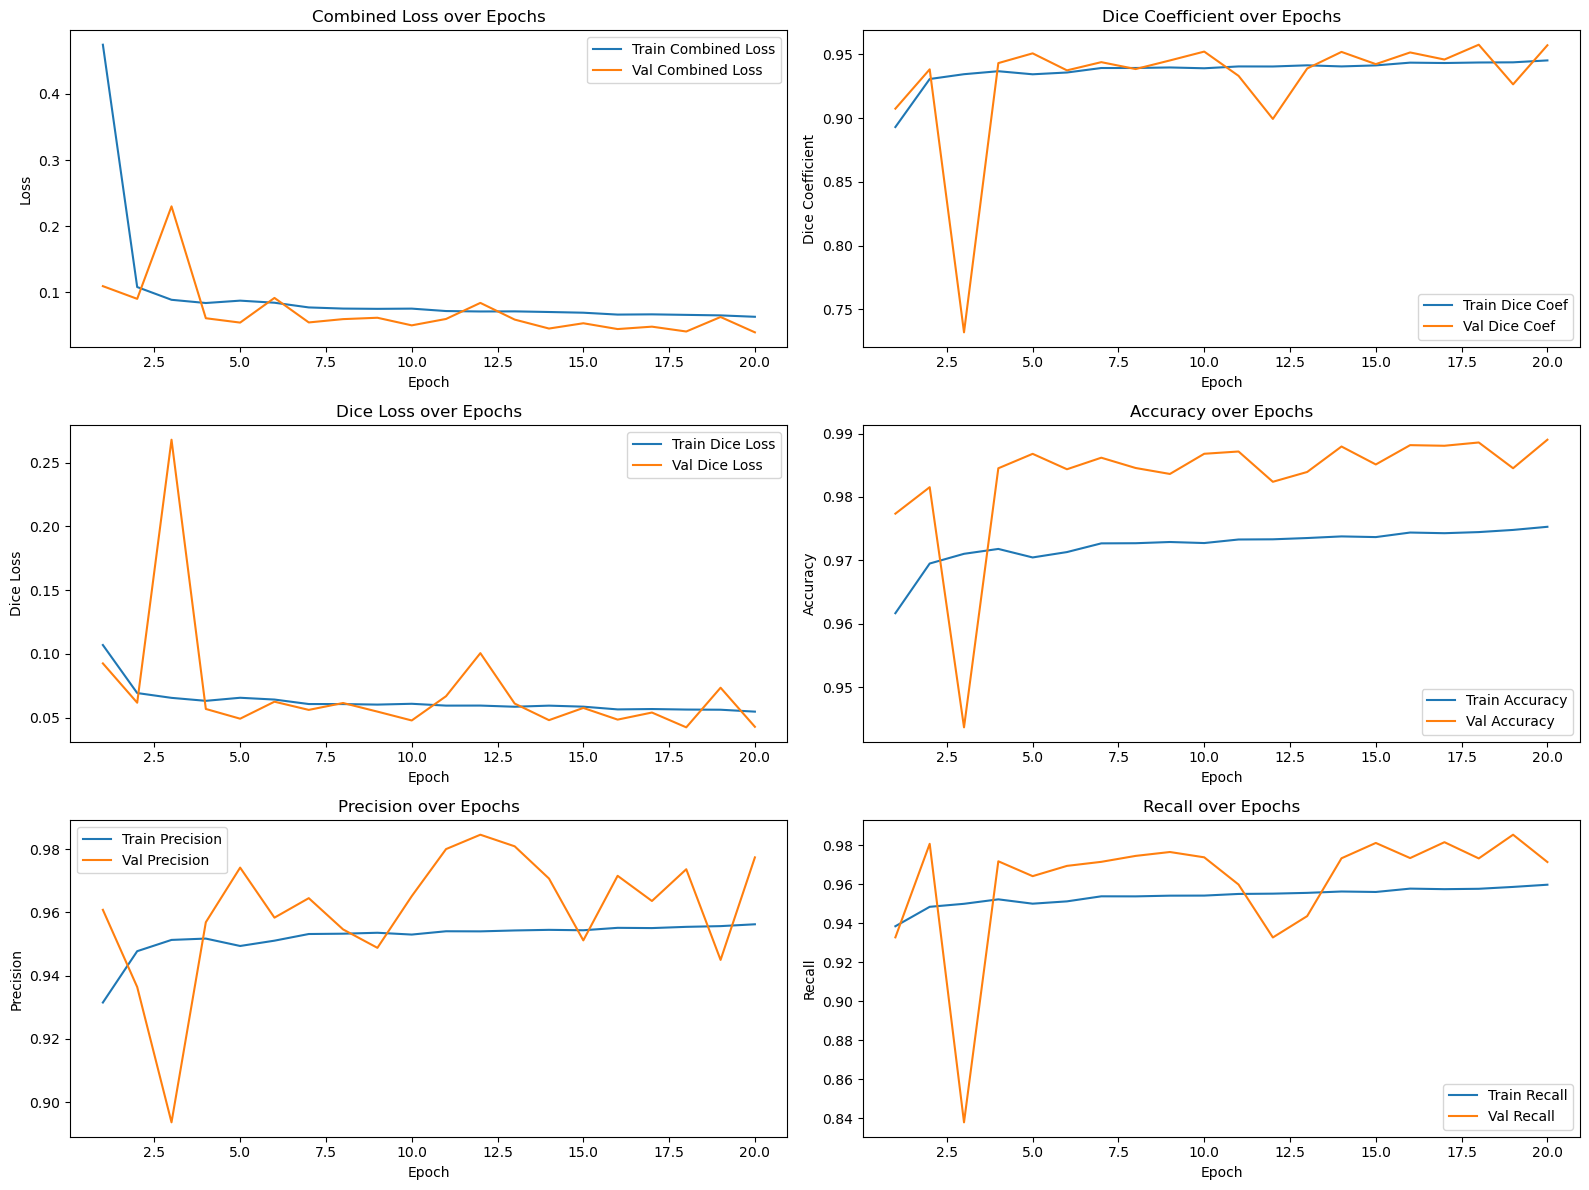


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_10.3_2025-04-01-21-08\Model_Data
138/138 [==============================] - 30s 217ms/step - loss: 0.0667 - accuracy: 0.9861 - precision: 0.9374 - recall: 0.9639 - dice_coef: 0.9103


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_10.3
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/9c238881c5464ccba5eaf8934ae4c836
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                       : (0.9616889953613281, 0.975304126739502)
COMET INFO:     batch_accuracy [2760]               : (0.6819777488708496, 0.9931304454803467)
COMET INFO:     batch_dice_coef [2760]              : (0.4458378255367279, 0.9811137318611145)
COMET INFO:     batch_loss [2760]                   : (0.025099806487560272, 47.06779861450195)
COMET INFO:     batch_precision [2760]              : (0.47383394837379456, 0.9950149655342102)
COME

In [6]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.5, 0.1)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_10.3"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

In [7]:
# --- Bin the 70% training split for training ---
snow_vs_notsnow_ratio_distribution = (0.95, 0.05)  # (high_threshold, low_threshold)

low_bin, mid_bin, high_bin = bin_tile_pairs(train_split, snow_vs_notsnow_ratio_distribution)
print(f"Training bins (70% split): Low: {len(low_bin)}, Mid: {len(mid_bin)}, High: {len(high_bin)}")
training_bins = (low_bin, mid_bin, high_bin)

Training bins (70% split): Low: 56965, Mid: 14329, High: 11333


Training tiles selected (after binning): 22000

Final split counts:
Number of training pairs: 22000
Number of in-sample validation pairs: 4400
Number of in-sample testing pairs: 2200
Number of out-of-sample testing pairs: 2200
Model summary:
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_33 (Conv2D)             (None, 512, 512, 16  432         ['input_2[0][0]']                
                                )                                                                 
                                                

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/935281dc217e4516aac651bedf6f47e8

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 1375
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


1375/1375 [==============================] - ETA: 0s - loss: 0.4286 - accuracy: 0.9588 - precision_1: 0.9582 - recall_1: 0.9578 - dice_coef: 0.9270   
Epoch 1: val_loss improved from inf to 0.12342, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
1375/1375 [==============================] - 503s 363ms/step - loss: 0.4286 - accuracy: 0.9588 - precision_1: 0.9582 - recall_1: 0.9578 - dice_coef: 0.9270 - val_loss: 0.1234 - val_accuracy: 0.9702 - val_precision_1: 0.9946 - val_recall_1: 0.8663 - val_dice_coef: 0.9030
Epoch 2/20
1375/1375 [==============================] - ETA: 0s - loss: 0.0964 - accuracy: 0.9685 - precision_1: 0.9672 - recall_1: 0.9686 - dice_coef: 0.9561  
Epoch 2: val_loss improved from 0.12342 to 0.09001, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
E

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:258: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,0].legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:268: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,1].legend()


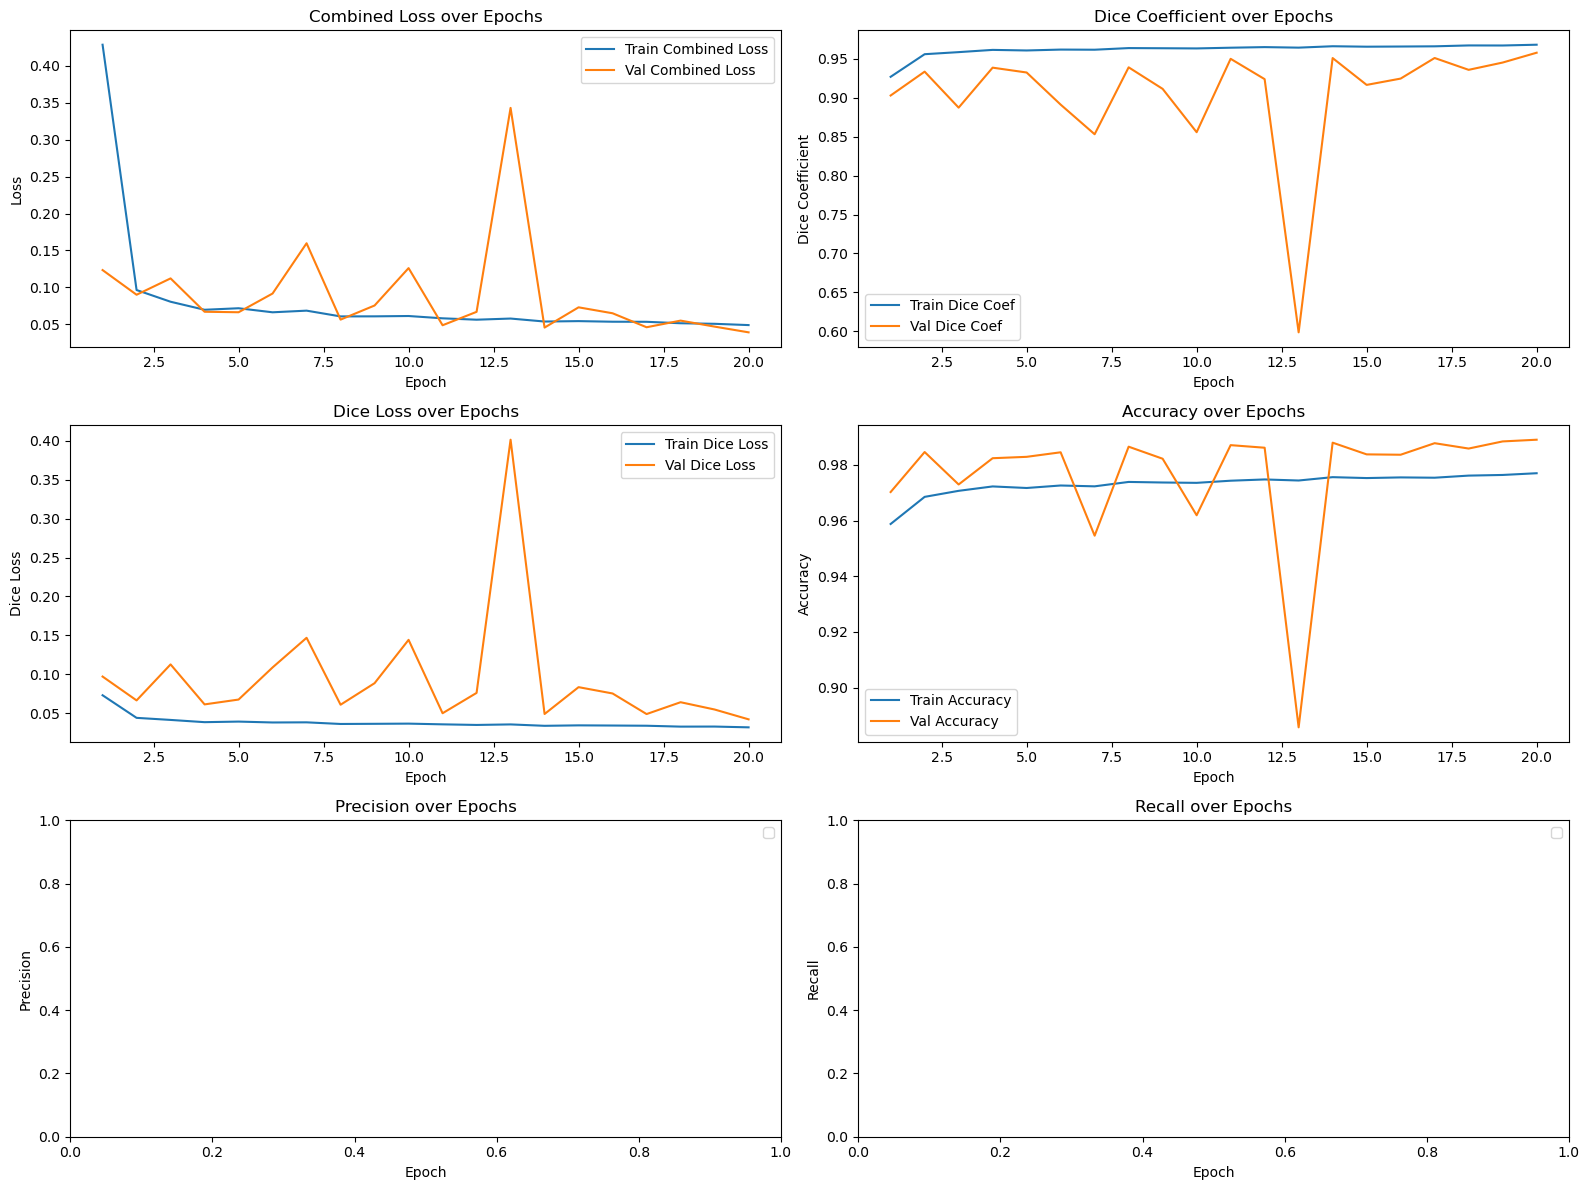


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.1_2025-04-01-23-57\Model_Data
138/138 [==============================] - 30s 216ms/step - loss: 0.0628 - accuracy: 0.9868 - precision_1: 0.9433 - recall_1: 0.9627 - dice_coef: 0.9164


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_11.1
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/935281dc217e4516aac651bedf6f47e8
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                       : (0.958767294883728, 0.9769920706748962)
COMET INFO:     batch_accuracy [2760]               : (0.4164457321166992, 0.9825787544250488)
COMET INFO:     batch_dice_coef [2760]              : (0.5276691913604736, 0.9808831810951233)
COMET INFO:     batch_loss [2760]                   : (0.03671235963702202, 47.104896545410156)
COMET INFO:     batch_precision_1 [2760]            : (0.500669002532959, 0.9933532476425171)
COMET 

In [8]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.3, 0.3)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_11.1"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

Training tiles selected (after binning): 22000

Final split counts:
Number of training pairs: 22000
Number of in-sample validation pairs: 4400
Number of in-sample testing pairs: 2200
Number of out-of-sample testing pairs: 2200
Model summary:
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_66 (Conv2D)             (None, 512, 512, 16  432         ['input_3[0][0]']                
                                )                                                                 
                                                

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/d23afd9a8944475a86b4d7ded5d511e2

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 1375
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


1375/1375 [==============================] - ETA: 0s - loss: 0.4940 - accuracy: 0.9633 - precision_2: 0.9524 - recall_2: 0.9538 - dice_coef: 0.9239   
Epoch 1: val_loss improved from inf to 0.68030, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
1375/1375 [==============================] - 506s 366ms/step - loss: 0.4940 - accuracy: 0.9633 - precision_2: 0.9524 - recall_2: 0.9538 - dice_coef: 0.9239 - val_loss: 0.6803 - val_accuracy: 0.7853 - val_precision_2: 0.9959 - val_recall_2: 0.0018 - val_dice_coef: 0.2483
Epoch 2/20
1375/1375 [==============================] - ETA: 0s - loss: 0.0966 - accuracy: 0.9707 - precision_2: 0.9619 - recall_2: 0.9633 - dice_coef: 0.9488  
Epoch 2: val_loss improved from 0.68030 to 0.22959, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
E

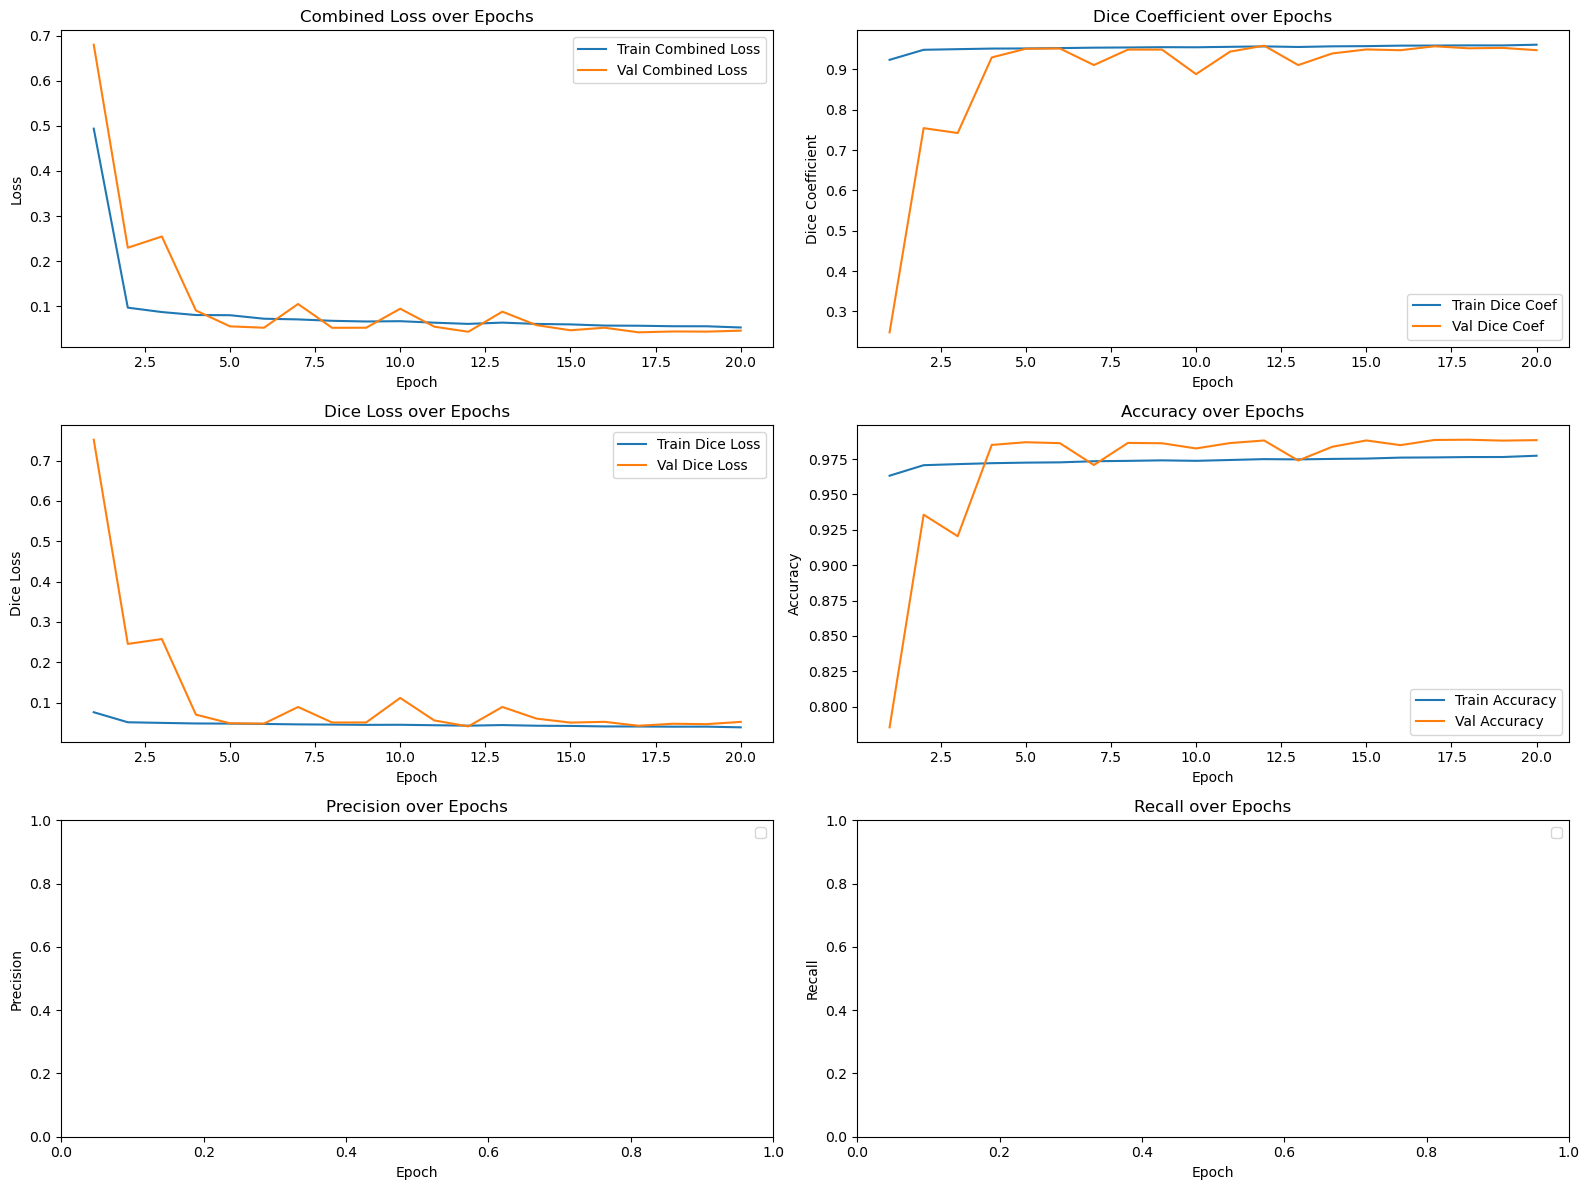


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.2_2025-04-02-02-45\Model_Data
138/138 [==============================] - 30s 217ms/step - loss: 0.0986 - accuracy: 0.9780 - precision_2: 0.8867 - recall_2: 0.9644 - dice_coef: 0.8712


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_11.2
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/d23afd9a8944475a86b4d7ded5d511e2
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                       : (0.9632753729820251, 0.9773948192596436)
COMET INFO:     batch_accuracy [2760]               : (0.43149518966674805, 0.9921112060546875)
COMET INFO:     batch_dice_coef [2760]              : (0.38138848543167114, 0.9870538115501404)
COMET INFO:     batch_loss [2760]                   : (0.021751541644334793, 47.189979553222656)
COMET INFO:     batch_precision_2 [2760]            : (0.2567843496799469, 0.9912134408950806)
C

In [9]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.4, 0.2)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_11.2"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

Training tiles selected (after binning): 22000

Final split counts:
Number of training pairs: 22000
Number of in-sample validation pairs: 4400
Number of in-sample testing pairs: 2200
Number of out-of-sample testing pairs: 2200
Model summary:
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_99 (Conv2D)             (None, 512, 512, 16  432         ['input_4[0][0]']                
                                )                                                                 
                                                

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/1009412004514d5691183af2929f5ad6

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 1375
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


1375/1375 [==============================] - ETA: 0s - loss: 0.5095 - accuracy: 0.9603 - precision_3: 0.9284 - recall_3: 0.9362 - dice_coef: 0.8810   
Epoch 1: val_loss improved from inf to 0.19302, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
1375/1375 [==============================] - 507s 367ms/step - loss: 0.5095 - accuracy: 0.9603 - precision_3: 0.9284 - recall_3: 0.9362 - dice_coef: 0.8810 - val_loss: 0.1930 - val_accuracy: 0.9490 - val_precision_3: 0.8332 - val_recall_3: 0.9538 - val_dice_coef: 0.8300
Epoch 2/20
1375/1375 [==============================] - ETA: 0s - loss: 0.0999 - accuracy: 0.9709 - precision_3: 0.9489 - recall_3: 0.9514 - dice_coef: 0.9314  
Epoch 2: val_loss improved from 0.19302 to 0.06755, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
E

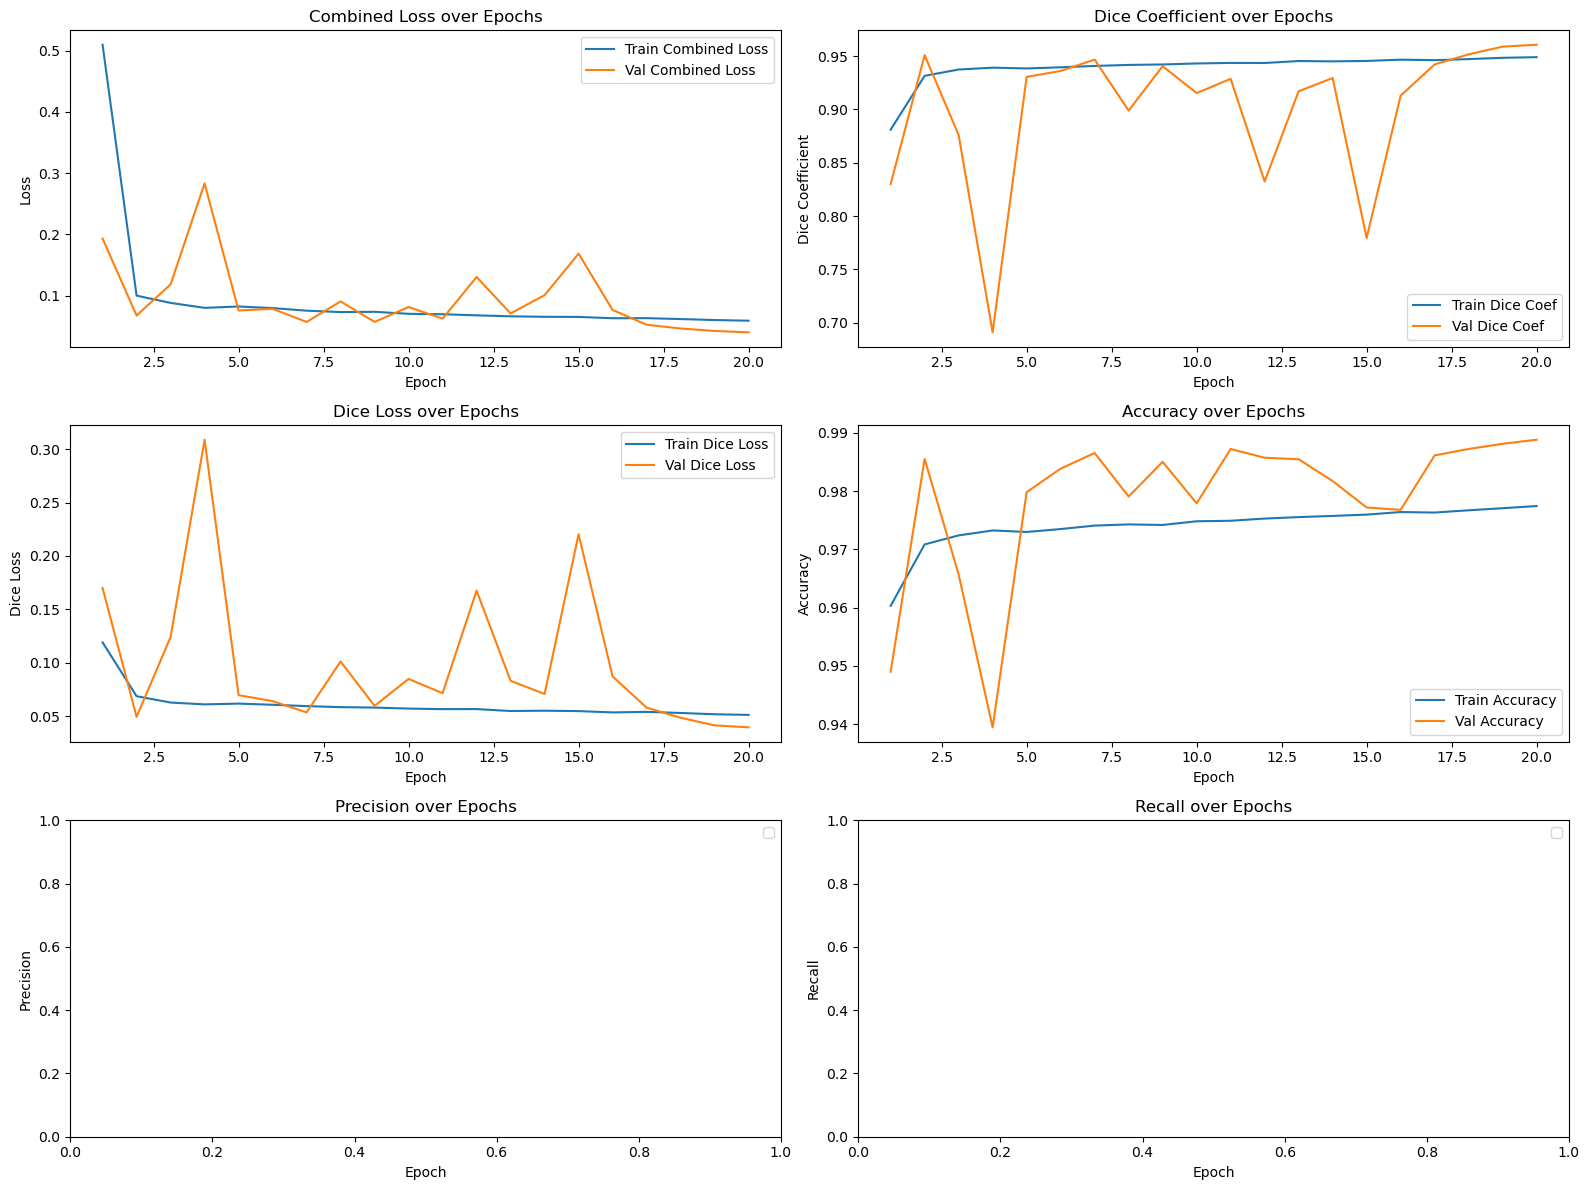


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_11.3_2025-04-02-05-33\Model_Data
138/138 [==============================] - 30s 218ms/step - loss: 0.0739 - accuracy: 0.9832 - precision_3: 0.9086 - recall_3: 0.9771 - dice_coef: 0.9090


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_11.3
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/1009412004514d5691183af2929f5ad6
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                       : (0.9603004455566406, 0.977443516254425)
COMET INFO:     batch_accuracy [2760]               : (0.5379431247711182, 0.9898912906646729)
COMET INFO:     batch_dice_coef [2760]              : (0.3971804082393646, 0.9539946913719177)
COMET INFO:     batch_loss [2760]                   : (0.048393622040748596, 47.158958435058594)
COMET INFO:     batch_precision_3 [2760]            : (0.3088175356388092, 0.9967471957206726)
COME

In [10]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.5, 0.1)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_11.3"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

In [11]:
# --- Bin the 70% training split for training ---
snow_vs_notsnow_ratio_distribution = (0.99, 0.01)  # (high_threshold, low_threshold)

low_bin, mid_bin, high_bin = bin_tile_pairs(train_split, snow_vs_notsnow_ratio_distribution)
print(f"Training bins (70% split): Low: {len(low_bin)}, Mid: {len(mid_bin)}, High: {len(high_bin)}")
training_bins = (low_bin, mid_bin, high_bin)

Training bins (70% split): Low: 54919, Mid: 18030, High: 9678


In [ ]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.3, 0.3)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_12.1"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

Training tiles selected (after binning): 22000

Final split counts:
Number of training pairs: 22000
Number of in-sample validation pairs: 4400
Number of in-sample testing pairs: 2200
Number of out-of-sample testing pairs: 2200
Model summary:
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_132 (Conv2D)            (None, 512, 512, 16  432         ['input_5[0][0]']                
                                )                                                                 
                                                

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/cd28b4353583462fabbb5334df65b208

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 1375
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


1375/1375 [==============================] - ETA: 0s - loss: 0.4133 - accuracy: 0.9626 - precision_4: 0.9618 - recall_4: 0.9614 - dice_coef: 0.9375   
Epoch 1: val_loss improved from inf to 0.12915, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
1375/1375 [==============================] - 503s 364ms/step - loss: 0.4133 - accuracy: 0.9626 - precision_4: 0.9618 - recall_4: 0.9614 - dice_coef: 0.9375 - val_loss: 0.1292 - val_accuracy: 0.9748 - val_precision_4: 0.9149 - val_recall_4: 0.9732 - val_dice_coef: 0.8903
Epoch 2/20
1375/1375 [==============================] - ETA: 0s - loss: 0.0869 - accuracy: 0.9720 - precision_4: 0.9718 - recall_4: 0.9706 - dice_coef: 0.9599  
Epoch 2: val_loss improved from 0.12915 to 0.07891, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
E

In [ ]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.4, 0.2)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_12.2"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

In [ ]:
# Distribution for sampling training bins.
mid_low_high_ratio_distribution = (0.4, 0.5, 0.1)  # (mid, low, high)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_12.3"

# Run training.
model, history, in_sample_eval, out_of_sample_eval = run_unet_training(
    folder_path=folder_path,
    training_bins=training_bins,
    in_sample_val_tiles=in_sample_val_tiles,
    in_sample_test_tiles=in_sample_test_tiles,
    out_of_sample_test_tiles=out_of_sample_test_tiles,
    max_training_tiles=max_training_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)